# Elder Solution

In [15]:
# -- import libraries --
import numpy as np
import matplotlib.pyplot as plt
import json

plt.style.use(["seaborn-v0_8-darkgrid", "seaborn-v0_8-colorblind", "seaborn-v0_8-paper"])
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.shadow"] = True
plt.rcParams["legend.framealpha"] = 0.1

In [16]:
# -- import solution data --
solution_file = 'ex7Elder.json'
with open(solution_file, 'r') as file:
    solution_data = json.load(file)
    coords = np.array(solution_data["coords"])
    triangles = np.array(solution_data["triangles"])
    t_eval = np.array(solution_data["t_eval"])
    U = np.array(solution_data["U"])

N = coords.shape[0]

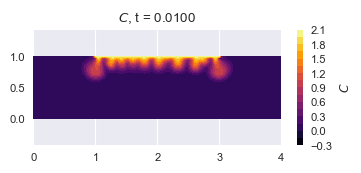

In [17]:
fig = plt.figure(figsize=(4,1.5))

idx = 2
cont = plt.tricontourf(
    coords[:,0],
    coords[:,1],
    U[N:,idx],
    cmap="inferno",
    levels=20
)
fig.colorbar(cont, label="$C$")
plt.title(f"$C$, t = {t_eval[idx]:.4f}")
plt.axis("equal")
plt.savefig("../figures/elder-gfdflow.png", dpi=1000, bbox_inches="tight")

plt.show()

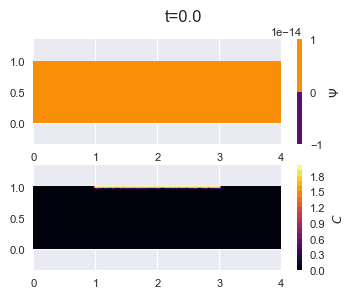

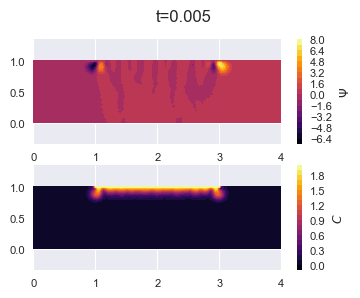

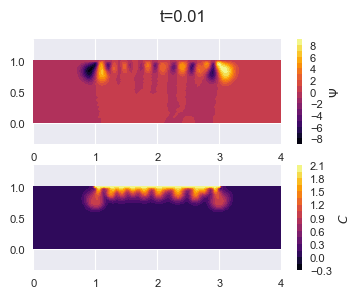

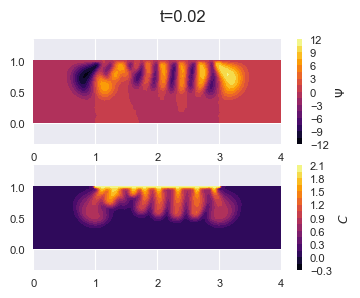

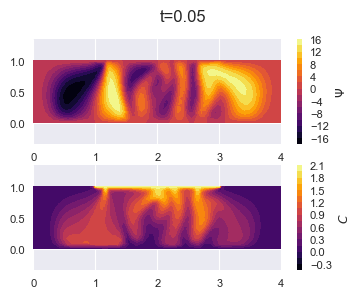

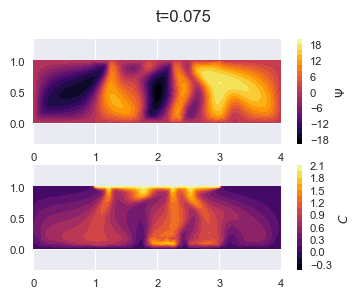

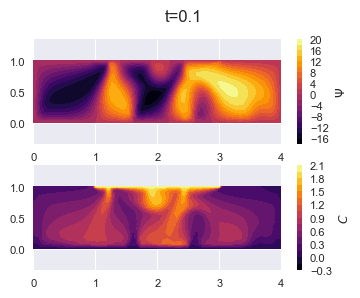

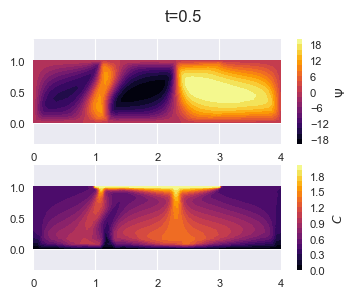

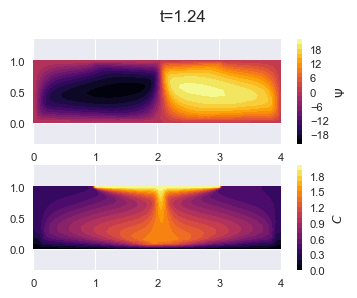

In [18]:
from matplotlib.animation import FuncAnimation
for idx in range(len(t_eval)):
    fig = plt.figure(figsize=(4,3))

    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,1,2)

    cont1 = ax1.tricontourf(
        coords[:,0],
        coords[:,1],
        U[:N,idx],
        cmap="inferno",
        levels=20
    )
    fig.colorbar(cont1, label=r"$\Psi$")
    ax1.axis("equal")

    cont2 = ax2.tricontourf(
        coords[:,0],
        coords[:,1],
        U[N:,idx],
        cmap="inferno",
        levels=20
    )
    fig.colorbar(cont2, label="$C$")
    ax2.axis("equal")

    fig.suptitle(f"t={t_eval[idx]:1.3}")

    # optional: save figure
    # plt.savefig(f"../figures/ex7Elder_{t_eval[idx]:1.3f}.png", dpi=1000, bbox_inches="tight")

plt.show()



In [19]:
# gif
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

cont1 = ax1.tricontourf(
    coords[:, 0],
    coords[:, 1],
    U[:N, 0],
    cmap="inferno",
    levels=20
)
fig.colorbar(cont1, label=r"$\Psi$")
ax1.axis("equal")
ax1.set_title(f"t={t_eval[0]:1.3}")

cont2 = ax2.tricontourf(
    coords[:, 0],
    coords[:, 1],
    U[N:, 0],
    cmap="inferno",
    levels=20
)
fig.colorbar(cont2, label="$C$")
ax2.axis("equal")

def update(frame):
    ax1.clear()
    ax2.clear()

    cont1 = ax1.tricontourf(
        coords[:, 0],
        coords[:, 1],
        U[:N, frame],
        cmap="inferno",
        levels=20
    )
    ax1.axis("equal")
    ax1.set_title(f"t={t_eval[frame]:1.3}")

    cont2 = ax2.tricontourf(
        coords[:, 0],
        coords[:, 1],
        U[N:, frame],
        cmap="inferno",
        levels=20
    )
    ax2.axis("equal")

    return cont1, cont2

ani = FuncAnimation(fig, update, frames=U.shape[1], blit=False, interval=1)

ani.save("../figures/ex7Elder.gif", writer='pillow', fps=1)

plt.close(fig)

print("Done!")


Done!


### Solution GIF

![elder_sol](../figures/ex7Elder.gif)